## Libraries Import

In [1]:
import os
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tarfile

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

from sklearn.model_selection import cross_val_predict,cross_val_score

from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,precision_recall_curve,roc_auc_score,roc_curve,confusion_matrix,classification_report

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import optuna
from optuna.visualization import plot_optimization_history,plot_parallel_coordinate,plot_slice,plot_contour,plot_param_importances

import regex as re
import emoji

import nltk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.model_selection import StratifiedKFold


In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')             

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mayankgaur/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mayankgaur/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/mayankgaur/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
with tarfile.open("files/hard_ham.tar.bz2") as tar:
    tar.extractall(path="files/data/")

In [4]:
with tarfile.open("files/hard_spam.tar.bz2") as tar:
    tar.extractall(path="files/data/")

## Text Extractions

In [5]:
def func(folder,label):
    emails=[]
    for file_name in os.listdir(folder):
        file_path=os.path.join(folder,file_name)
        if os.path.isfile(file_path):
            with open(file_path,"r",encoding="latin1") as f:
                emails.append((f.read(),label))
    return emails

In [6]:
ham=func("files/data/hard_ham/","ham")
spam=func("files/data/spam//","spam")

In [7]:
data=ham+spam
data=np.array(data)
data[0]

array(['Return-Path: <bounce-lghtml-2534368@sprocket.lockergnome.com>\nReceived: from lockergnome.com (sprocket.lockergnome.com [130.94.96.247])\n\tby dogma.slashnull.org (8.11.6/8.11.6) with SMTP id g6IKksJ07017\n\tfor <qqqqqqqqqq-lg@spamassassin.taint.org>; Thu, 18 Jul 2002 21:46:54 +0100\nX-Mailer: ListManager Web Interface\nDate: Thu, 18 Jul 2002 09:55:22 -0500\nSubject: [Lockergnome Windows Daily]  Sticker Courtesy\nTo: qqqqqqqqqq-lg@spamassassin.taint.org\nFrom: Lockergnome Windows Daily <subscriptions@lockergnome.com>\nList-Unsubscribe: <mailto:leave-lghtml-2534368N@sprocket.lockergnome.com>\nList-Subscribe: <mailto:subscribe-lghtml@sprocket.lockergnome.com>\nList-Owner: <mailto:owner-lghtml@sprocket.lockergnome.com>\nX-URL: <http://www.lockergnome.com/>\nX-List-Host: Lockergnome <http://www.lockergnome.com/>\nReply-To: leave-lghtml-2534368N@sprocket.lockergnome.com\nSender: bounce-lghtml-2534368@sprocket.lockergnome.com\nMessage-Id: <LISTMANAGERSQL-2534368-1682723-2002.07.18-09

In [8]:
data.ndim

2

## Data Cleaning

In [9]:
X,y=data[:,0],data[:,1]

In [10]:
stemmer=PorterStemmer()
stop_words=set(stopwords.words("english"))

def data_cleaning(text):
    text=text.lower()
    text=re.sub(r'<[^>]+>', ' ', text)  # remove headers
    text=re.sub(r"http\S+|www\S+","URL",text)   # change website to URL
    text=re.sub(r"\d","NUMBERS",text)   # removenumbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove punch
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra space
    text=emoji.demojize(text)
    filtered_txt=[]
    for word in text.split(" "):
        if word in stop_words:
            continue
        filtered_txt.append(stemmer.stem(word))
    return " ".join(filtered_txt)
    

In [11]:
X=[data_cleaning(text) for text in X]

## Splitting The Data

In [12]:
y=np.where(y=="ham",0,1)

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42,shuffle=True)

## Without data cleaning

## Vectorizer

In [14]:
vectorizer=TfidfVectorizer()

In [15]:
X_train_prep=vectorizer.fit_transform(X_train)
X_test_prep=vectorizer.transform(X_test)

## Model Training

In [16]:
def evaluator(model,feature,target):
    predictions=cross_val_predict(model,feature,target,cv=3,method="predict")
    score=cross_val_predict(model,feature,target,cv=3,method="predict_proba")[:,1]
    Dict={"accuracy":None,"precision":None,"recall":None,"f1":None,"area":None,}
    Dict["accuracy"]=accuracy_score(target,predictions)
    Dict["precision"]=precision_score(target,predictions)
    Dict["recall"]=recall_score(target,predictions)
    Dict["f1"]=f1_score(target,predictions)
    Dict["area"]=roc_auc_score(target,score)
    clf_report=classification_report(target,predictions)
    data=pd.DataFrame(Dict,index=[model.__class__.__name__])

    fig,ax=plt.subplots(2,2,figsize=(10,4))
    prec,rec,threshold=precision_recall_curve(target,score)
    fpr,tpr,thres=roc_curve(target,score)
    ax[0][0].plot(prec,rec,label="curve",color="red")
    ax[0][0].set_xlabel("precision")
    ax[0][0].set_ylabel("recall")

    ax[0][1].plot(threshold,prec[:-1],label="prec_rec")
    ax[0][1].plot(threshold,rec[:-1],label="prec_rec")
    ax[0][1].set_xlabel("threshold")
    ax[0][1].set_ylabel("values")

    ax[1][0].plot(fpr,tpr,label="fpr_tpr_curve")
    ax[1][0].set_xlabel("fpr")
    ax[1][0].set_ylabel("tpr")

    sns.heatmap(confusion_matrix(target,predictions),annot=True,ax=ax[1][1],cmap="Blues")
    plt.tight_layout()

    plt.show()
    
    print(clf_report)
    return data

    
    
    
    

model started


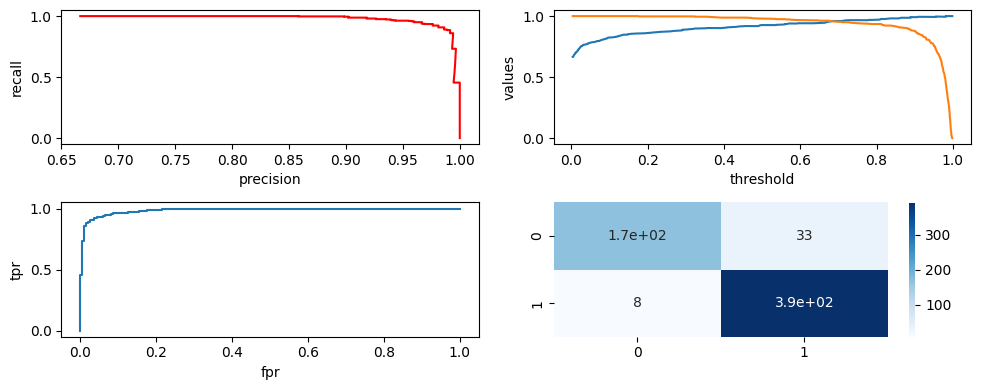

              precision    recall  f1-score   support

           0       0.95      0.83      0.89       200
           1       0.92      0.98      0.95       400

    accuracy                           0.93       600
   macro avg       0.94      0.91      0.92       600
weighted avg       0.93      0.93      0.93       600

----------------------------------------------------------------------------------------------------
model started


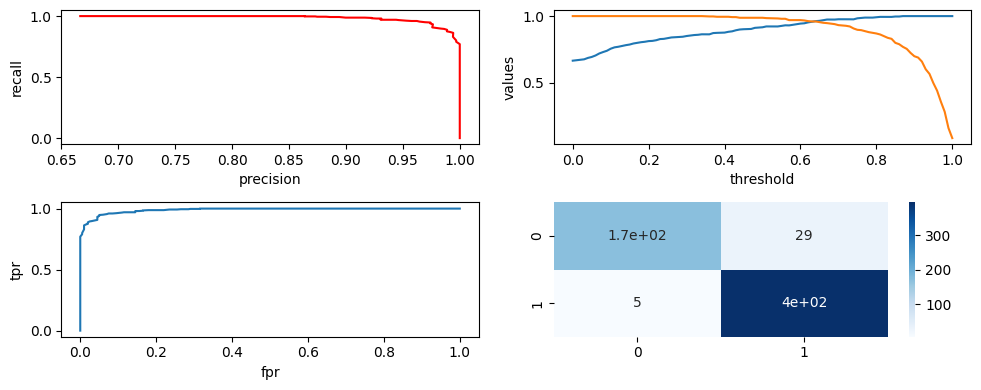

              precision    recall  f1-score   support

           0       0.97      0.85      0.91       200
           1       0.93      0.99      0.96       400

    accuracy                           0.94       600
   macro avg       0.95      0.92      0.93       600
weighted avg       0.94      0.94      0.94       600

----------------------------------------------------------------------------------------------------
model started


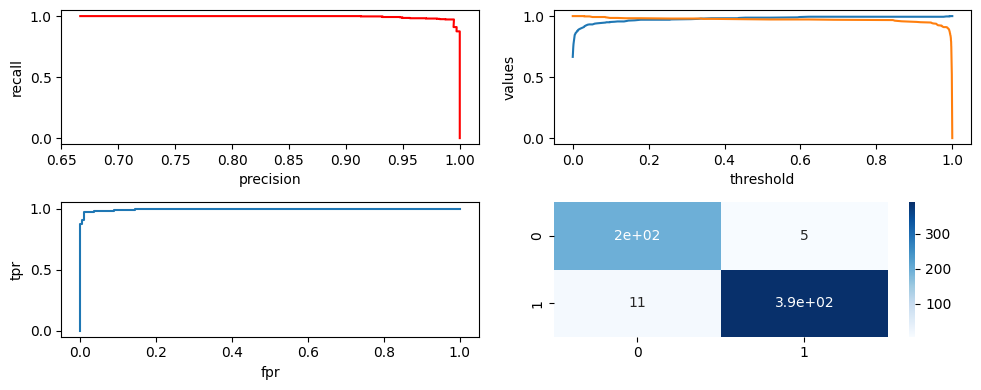

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       200
           1       0.99      0.97      0.98       400

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600

----------------------------------------------------------------------------------------------------


In [17]:
models=[SGDClassifier(loss="log_loss"),RandomForestClassifier(),XGBClassifier()]
result=[]
for model in models:
    print("model started")
    res=evaluator(model,X_train_prep,y_train)
    result.append(res)
    print("--"*50)    

In [18]:
pd.concat([result[0],result[1],result[2]],axis=0)

,accuracy,precision,recall,f1,area
SGDClassifier,0.931667,0.922353,0.9800,0.950303,0.986700
RandomForestClassifier,0.943333,0.931604,0.9875,0.958738,0.988619
XGBClassifier,0.973333,0.987310,0.9725,0.979849,0.996575


## Hyperparameter Tuning

In [19]:
def objective(trail):
    params={"n_estimators":trail.suggest_int("n_estimators",100,1000),
            "max_depth":trail.suggest_int("max_depth",2,10),
            "learning_rate":trail.suggest_float("learning_rate",0.01,0.25),
            "subsample":trail.suggest_float("subsample",0.5,1.0),
            "min_child_weight":trail.suggest_int("min_child_weight",5,20)}
    model=XGBClassifier(**params)
    cv=StratifiedKFold(n_splits=5,random_state=42,shuffle=True)
    accuracy=cross_val_score(model,X_train_prep,y_train,cv=cv,scoring="accuracy")

    return accuracy.mean()
            
            

In [20]:
study=optuna.create_study(direction="maximize",)
study.optimize(objective,n_trials=50,show_progress_bar=True)

[I 2026-02-13 14:11:39,135] A new study created in memory with name: no-name-e855e012-55f4-4213-a0ee-41a418e9162a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-13 14:11:42,409] Trial 0 finished with value: 0.9549999999999998 and parameters: {'n_estimators': 447, 'max_depth': 9, 'learning_rate': 0.1879428897583985, 'subsample': 0.9560520236662715, 'min_child_weight': 12}. Best is trial 0 with value: 0.9549999999999998.
[I 2026-02-13 14:11:49,721] Trial 1 finished with value: 0.9366666666666668 and parameters: {'n_estimators': 987, 'max_depth': 8, 'learning_rate': 0.05580224651239522, 'subsample': 0.8277800248212408, 'min_child_weight': 16}. Best is trial 0 with value: 0.9549999999999998.
[I 2026-02-13 14:11:56,073] Trial 2 finished with value: 0.9566666666666667 and parameters: {'n_estimators': 827, 'max_depth': 5, 'learning_rate': 0.1765821965965509, 'subsample': 0.934833916820122, 'min_child_weight': 7}. Best is trial 2 with value: 0.9566666666666667.
[I 2026-02-13 14:12:01,676] Trial 3 finished with value: 0.93 and parameters: {'n_estimators': 812, 'max_depth': 4, 'learning_rate': 0.21517427230873512, 'subsample': 0.6062982944271

In [21]:
print("best params",study.best_params)
print("best cv score",study.best_value)

best params {'n_estimators': 611, 'max_depth': 6, 'learning_rate': 0.012985109485623036, 'subsample': 0.8628582085273333, 'min_child_weight': 5}
best cv score 0.9716666666666667


In [22]:
plot_optimization_history(study).show()

In [23]:
plot_parallel_coordinate(study).show()

In [24]:
plot_slice(study).show()

In [25]:
plot_contour(study).show()

In [26]:
plot_param_importances(study).show()

In [27]:
def final(model,feature,target):
    predictions=model.predict(feature)
    score=model.predict_proba(feature)[:,1]
    Dict={"accuracy":None,"precision":None,"recall":None,"f1":None,"area":None,}
    Dict["accuracy"]=accuracy_score(target,predictions)
    Dict["precision"]=precision_score(target,predictions)
    Dict["recall"]=recall_score(target,predictions)
    Dict["f1"]=f1_score(target,predictions)
    Dict["area"]=roc_auc_score(target,score)
    clf_report=classification_report(target,predictions)
    data=pd.DataFrame(Dict,index=[model.__class__.__name__])

    fig,ax=plt.subplots(2,2,figsize=(10,4))
    prec,rec,threshold=precision_recall_curve(target,score)
    fpr,tpr,thres=roc_curve(target,score)
    ax[0][0].plot(prec,rec,label="curve",color="red")
    ax[0][0].set_xlabel("precision")
    ax[0][0].set_ylabel("recall")

    ax[0][1].plot(threshold,prec[:-1],label="prec_rec")
    ax[0][1].plot(threshold,rec[:-1],label="prec_rec")
    ax[0][1].set_xlabel("threshold")
    ax[0][1].set_ylabel("values")

    ax[1][0].plot(fpr,tpr,label="fpr_tpr_curve")
    ax[1][0].set_xlabel("fpr")
    ax[1][0].set_ylabel("tpr")

    sns.heatmap(confusion_matrix(target,predictions),annot=True,ax=ax[1][1],cmap="Blues")
    plt.tight_layout()

    plt.show()
    
    print(clf_report)
    return data

    
    
    
    

In [28]:
param_grid=study.best_params
final_model=XGBClassifier(**param_grid)

In [29]:
final_model.fit(X_train_prep,y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


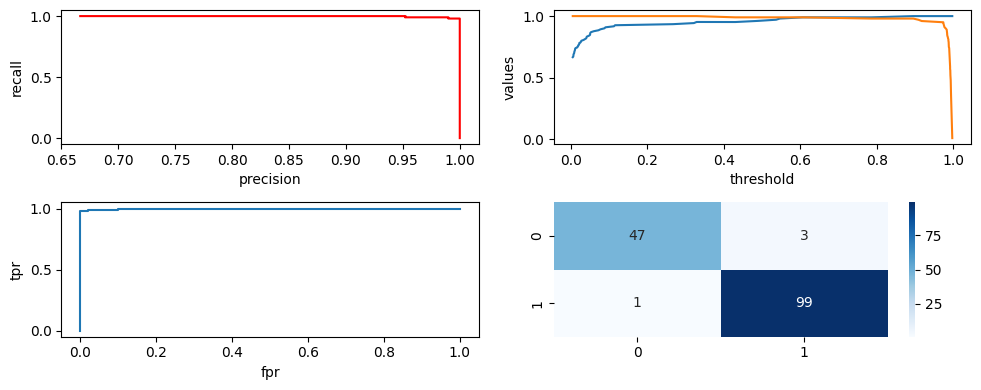

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        50
           1       0.97      0.99      0.98       100

    accuracy                           0.97       150
   macro avg       0.97      0.96      0.97       150
weighted avg       0.97      0.97      0.97       150



,accuracy,precision,recall,f1,area
XGBClassifier,0.973333,0.970588,0.99,0.980198,0.9988


In [30]:
final(final_model,X_test_prep,y_test)

In [31]:
import joblib

In [32]:
joblib.dump(final_model,"spam_classifier.pkl")

['spam_classifier.pkl']

In [33]:
joblib.dump(vectorizer,"spam_vectorizer.pkl")

['spam_vectorizer.pkl']